<a href="https://colab.research.google.com/github/mofurinosuke/XGboost-MA-trader/blob/main/XGboost_MA_model_ipynb.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ETH-JPYの1時間足トレードモデルのバックテスト

---
### はじめに：

開発した自動取引モデルのテストと、設計に用いた市場分析、理論について。

理論と実世界をつなぐ、適応システムの構築を目的として、いくつかプログラムを開発しました。バラバラだったそれらを再度結集し、このリポジトリにまとめ、データ分析から特徴量作成、行動ロジックまでこのプログラムだけで改良、実験できるようにしました。

### モデルの概要

このモデルの根底にあるのは、機械学習の予測と、数理モデルを用いたロジックです。多くの機械学習モデルは過去のデータパターンから未来を予測しようとします。しかし、機械学習だけではいい結果をあげることができませんでした。市場の動きには、ボラティリティの収束といった、統計学的なパターンが現れることがあります。これをダイレクトに捉える数理モデルを、特徴量ではなく、意思決定に、ダイレクトに接続することで、より強固なトレードモデルの構築を目指したものとなります。


### モデルの詳細
* XGBoostによる機械学習: 過去の価格データや市場指標から複雑なパターンを学習し、将来の価格変動を予測する役割を担います。一般的な機械学習モデルの一つでかつ比較的軽量に動くので、実験の試行回数を簡単に増やせます。
* ボラティリティ収束則の組み込み: ボラティリティ、つまり価格変動の大きさが移動平均(直近数日間の価格の平均値)へと収束する傾向を利用したオリジナルの数理モデルがトレードのシグナルを生成します。


---

---
###データ取得
このプロジェクトの最初のステップは、アルゴリズムトレードに必要な市場データを取得することでした。私は、仮想通貨取引所が提供する**APIを利用して、市場の価格データを自動的に収集しました。
###ローソク足データ

アルゴリズムトレードモデルは、単一の時点の価格だけでなく、一定期間の価格変動パターンを分析する必要があります。そこで用いたのが「ローソク足データ」です。

ローソク足データは、特定の時間枠（例：1分、1時間、1日）における価格の動きを、一本のローソクの形で視覚的に表現したものです。一本のローソク足には、以下の4つの重要な情報が詰まっています。

* 始値（Open）: その時間枠の最初の取引価格

* 高値（High）: その時間枠の最高価格

* 安値（Low）: その時間枠の最低価格

* 終値（Close）: その時間枠の最後の取引価格

ローソク足の「胴体」の色（緑や赤など）や長さは、価格がその時間枠でどれだけ変動したかを示し、「ヒゲ」の長さは最高値と最低値の幅を表します。


---
###必要なライブラリをインストール

In [ ]:
!pip install arch

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 981.3/981.3 kB 11.9 MB/s eta 0:00:00


In [ ]:
!pip install ta

  Preparing metadata (setup.py) ... done
  Created wheel for ta: filename=ta-0.11.0-py3-none-any.whl size=29412 sha256=727231cc327442ee9b015f89cf39d420f079e4faacbc80e75bd18cf6c6713fcd
  Stored in directory: /root/.cache/pip/wheels/5c/a1/5f/c6b85a7d9452057be4ce68a8e45d77ba34234a6d46581777c6
Successfully built ta


In [ ]:
!pip install japanize-matplotlib

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.1/4.1 MB 38.2 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for japanize-matplotlib: filename=japanize_matplotlib-1.1.3-py3-none-any.whl size=4120257 sha256=54da1eed80e97a08f19e507b8dfe67cb14eb9444b49e500bbf84c32730672c07
  Stored in directory: /root/.cache/pip/wheels/c1/f7/9b/418f19a7b9340fc16e071e89efc379aca68d40238b258df53d
Successfully built japanize-matplotlib


---
###データ整形
CSVファイルに別々に保存した、ETH_JPYとBTC_JPYの4本足データを時間がずれないように一つにまとめ、df_rawに代入します。



In [ ]:
import pandas as pd

def load_and_align(csv_eth, csv_btc):

    eth = pd.read_csv(csv_eth, parse_dates=["timestamp"])
    btc = pd.read_csv(csv_btc, parse_dates=["timestamp"])
    eth = eth.set_index("timestamp")
    btc = btc.set_index("timestamp")
    eth = eth.resample("1H").agg({
        "open": "first",
        "high": "max",
        "low": "min",
        "close": "last",
        "volume": "sum"
    })
    btc = btc.resample("1H").agg({
        "open": "first",
        "high": "max",
        "low": "min",
        "close": "last",
        "volume": "sum"
    })
    aligned = eth.join(btc, how="inner", lsuffix="_eth", rsuffix="_btc")

    return aligned

eth = "/content/eth_jpy_data_2021_2025_1h.csv"
btc ="/content/btc_jpy_data_2017_2025_1h.csv"
df_raw = load_and_align(eth, btc)


/tmp/ipykernel_379/422361784.py:9: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  eth = eth.resample("1H").agg({
/tmp/ipykernel_379/422361784.py:16: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  btc = btc.resample("1H").agg({


まとめたデータを確認してみましょう。

In [ ]:
df_raw.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 40467 entries, 2021-01-01 00:00:00 to 2025-08-14 02:00:00
Freq: h
Data columns (total 10 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   open_eth    40467 non-null  float64
 1   high_eth    40467 non-null  float64
 2   low_eth     40467 non-null  float64
 3   close_eth   40467 non-null  float64
 4   volume_eth  40467 non-null  float64
 5   open_btc    40467 non-null  float64
 6   high_btc    40467 non-null  float64
 7   low_btc     40467 non-null  float64
 8   close_btc   40467 non-null  float64
 9   volume_btc  40467 non-null  float64
dtypes: float64(10)
memory usage: 3.4 MB


In [ ]:
df_raw

,open_eth,high_eth,low_eth,close_eth,volume_eth,open_btc,high_btc,low_btc,close_btc,volume_btc
timestamp,,,,,,,,,,
2021-01-01 00:00:00,75542.0,75750.0,74997.0,75340.0,885.4070,2969978.0,2976000.0,2948000.0,2974047.0,41.8649
2021-01-01 01:00:00,75358.0,76498.0,75122.0,76413.0,1957.5159,2973021.0,2995653.0,2970999.0,2995000.0,115.0630
2021-01-01 02:00:00,76412.0,76483.0,76000.0,76333.0,1685.1488,2994999.0,2999193.0,2980857.0,2988496.0,74.4802
2021-01-01 03:00:00,76324.0,76597.0,76205.0,76345.0,897.9184,2988496.0,2998500.0,2987500.0,2994971.0,30.6458
2021-01-01 04:00:00,76345.0,76492.0,75753.0,76000.0,1953.9226,2994971.0,3000000.0,2977421.0,2990041.0,93.2649
...,...,...,...,...,...,...,...,...,...,...
2025-08-13 22:00:00,694419.0,702587.0,692866.0,696603.0,286.2189,18013562.0,18167000.0,18013562.0,18078107.0,17.8743
2025-08-13 23:00:00,696603.0,703888.0,696603.0,698930.0,250.3048,18078460.0,18181000.0,18078459.0,18134478.0,8.7241
2025-08-14 00:00:00,698929.0,698929.0,691923.0,692573.0,316.8497,18138050.0,18240000.0,18129999.0,18171876.0,39.8609


---
##特徴量作成





## 🧭 ADX:市場トレンドの定量化

"add_adx "関数で計算される。ADXはトレンドを表す指標として用います。

### 1. ADXを採用する理論的根拠

多くの価格予測モデル、特に順張り戦略は、強いトレンド環境でのみ高い性能を発揮します。逆に、価格が一定の範囲で動くレンジ環境では、誤ったシグナルを発しやすくなります。
今回は機械学習モデルに安定した順張りをさせることを目標としました。

### 2. ADXの構成要素とその意味

ADXは、以下の3つの主要な要素の組み合わせによって計算されます。

1.  **方向性ムーブメント（DM）の計算**:
    * **+DM**: 現在の高値が前日の高値をどれだけ上回ったか。
    * **-DM**: 前日の安値が現在の安値をどれだけ下回ったか。
    * これらは互いに排他的に計算されます。例えば、+DMが大きい場合、-DMはゼロです。
2.  **方向性指数（DI）の計算**:
    * +DI と -DI は、DMを True Range: TR(ボラティリティの大きさを表すもの。)
     で正規化したもので、買い圧力と売り圧力を百分率で示します。
3.  **ADXの計算**:
    * **DI** の差（$| +DI - -DI |$）を合計（$+DI + -DI$）で割った **DX** を修正移動平均したものがADXです。



---



In [ ]:
import pandas as pd
import numpy as np
import japanize_matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
from arch import arch_model
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA


#重いgarch関数を削除(2/27)
# ADXを計算する関数を定義
def add_adx(df, high_col, low_col, close_col, length=14):

    high = df[high_col]
    low = df[low_col]
    close = df[close_col]

    prev_high = high.shift(1)
    prev_low = low.shift(1)
    prev_close = close.shift(1)

    # +DM と -DM の計算
    plus_dm = high - prev_high
    minus_dm = prev_low - low

    # DMのフィルタリング: +DM > -DM かつ +DM > 0 の場合のみ値を残す
    plus_dm[(plus_dm < 0) | (plus_dm <= minus_dm)] = 0
    # DMのフィルタリング: -DM > +DM かつ -DM > 0 の場合のみ値を残す
    minus_dm[(minus_dm < 0) | (minus_dm <= plus_dm)] = 0

    #TR(True Range)を計算
    tr1 = high - low
    tr2 = abs(high - prev_close)
    tr3 = abs(low - prev_close)
    tr = pd.concat([tr1, tr2, tr3], axis=1).max(axis=1)

    # TR, +DM, -DMの平滑化（修正移動平均）
    atr = tr.ewm(alpha=1/length, adjust=False).mean()
    plus_di_smooth = plus_dm.ewm(alpha=1/length, adjust=False).mean()
    minus_di_smooth = minus_dm.ewm(alpha=1/length, adjust=False).mean()

    # +DI, -DIの計算
    plus_di = (plus_di_smooth / (atr + 1e-8)) * 100
    minus_di = (minus_di_smooth / (atr + 1e-8)) * 100

    # DX (Directional Index) の計算
    di_sum = plus_di + minus_di
    di_diff = abs(plus_di - minus_di)
    dx = (di_diff / (di_sum + 1e-8)) * 100

    # ADX (Average Directional Index) の計算 (DXの平滑化)
    adx = dx.ewm(alpha=1/length, adjust=False).mean()

    # DataFrameに列を追加
    # 注: 元のノートブックでは +DI, -DIは最終特徴量リストに含まれていないが、ADX計算のため内部で必要
    df[f'PLUS_DI_{length}'] = plus_di
    df[f'MINUS_DI_{length}'] = minus_di
    df[f'ADX_{length}'] = adx

    return df


#CREATEFUTURES=========
def create_final_features(df, ma_period=168,):

    df_feat = df.copy()

    eth_close = df_feat["close_eth"]
    btc_close = df_feat["close_btc"]
    eth_ret = eth_close.pct_change()
    btc_ret = btc_close.pct_change()

    # バックテストの add_vol_signals で必要なため ret_1h を作成
    df_feat["ret_1h"] = eth_ret

    # 2. BTCリターン (ret_btc_1h, ret_btc_24h)
    df_feat["ret_btc_1h"] = btc_ret
    df_feat["ret_btc_24h"] = btc_close.pct_change(24)

    # 3. 価格比率Zスコア ratio_z_score
    df_feat["price_ratio_eth_btc"] = eth_close / (btc_close + 1e-8)
    ratio_ma = df_feat["price_ratio_eth_btc"].rolling(ma_period).mean()
    ratio_std = df_feat["price_ratio_eth_btc"].rolling(ma_period).std()
    df_feat["ratio_z_score"] = (df_feat["price_ratio_eth_btc"] - ratio_ma) / (ratio_std + 1e-8)

    # 4. PCAはデータリーケージが発生したため削除2025/12/10

    # RSI
    #ewm:指数平滑移動平均　span=14 ならば、alpha = frac{2}{15} (0.133)
    delta = eth_close.diff()
    delta
    gain = np.where(delta > 0, delta, 0)
    loss = np.where(delta < 0, -delta, 0)
    avg_gain = pd.Series(gain, index=df_feat.index).ewm(span=14, adjust=False).mean()
    avg_loss = pd.Series(loss, index=df_feat.index).ewm(span=14, adjust=False).mean()
    rs = avg_gain / (avg_loss + 1e-8)
    df_feat["rsi_eth"] = 100 - (100 / (1 + rs))

    # MACD
    ema12 = eth_close.ewm(span=12).mean()
    ema26 = eth_close.ewm(span=26).mean()
    macd = ema12 - ema26
    signal = macd.ewm(span=9).mean()
    df_feat["macd_hist_eth"] = macd - signal

    # MA Dev & Vol Dist
    df_feat["ma_eth"] = eth_close.rolling(ma_period).mean()
    df_feat["ma_dev_eth"] = (eth_close - df_feat["ma_eth"]) / df_feat["ma_eth"]

    ma_std = eth_close.rolling(ma_period).std()
    df_feat["vol_dist_eth"] = (eth_close - df_feat["ma_eth"]) / (ma_std + 1e-8)


    # 6. 時間特徴量 (hour_sin, hour_cos, day_sin, day_cos)
    df_feat['hour_of_day'] = df_feat.index.hour
    df_feat['day_of_week'] = df_feat.index.dayofweek # 月曜日=0, 日曜日=6
    df_feat['hour_sin'] = np.sin(2 * np.pi * df_feat['hour_of_day'] / 24)
    df_feat['hour_cos'] = np.cos(2 * np.pi * df_feat['hour_of_day'] / 24)
    df_feat['day_sin'] = np.sin(2 * np.pi * df_feat['day_of_week'] / 7)
    df_feat['day_cos'] = np.cos(2 * np.pi * df_feat['day_of_week'] / 7)

    # 7. ADX
    print("Calculating ADX...")
    df_feat = add_adx(df_feat, high_col='high_eth', low_col='low_eth', close_col='close_eth', length=5)
    df_feat = add_adx(df_feat, high_col='high_eth', low_col='low_eth', close_col='close_eth', length=14)
    df_feat = add_adx(df_feat, high_col='high_eth', low_col='low_eth', close_col='close_eth', length=50)
    df_feat = add_adx(df_feat, high_col='high_eth', low_col='low_eth', close_col='close_eth', length=168)
    print("ADX calculation complete.")

    # 8. 最終クリーンアップ

    df_feat = df_feat.dropna()

    print("すべての特徴量作成が完了しました。")
    return df_feat


def save_features_to_csv(df_features, output_path="/content/2025futures.csv"):
    """
    生成された特徴量DataFrameをCSVファイルに出力する。
    """
    if df_features.empty:
        print("DataFrameが空のため、CSV出力はスキップされました。")
        return

    # インデックス（timestamp）を列として含めてCSVに出力
    df_features.to_csv(output_path, index=True)
    print(f"特徴量データが正常に {output_path} に出力されました。")



In [ ]:
df = create_final_features(df_raw)
save_features_to_csv(df)

Calculating ADX...
ADX calculation complete.
すべての特徴量作成が完了しました。
特徴量データが正常に /content/2025futures.csv に出力されました。


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 40300 entries, 2021-01-07 23:00:00 to 2025-08-14 02:00:00
Freq: h
Data columns (total 38 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   open_eth             40300 non-null  float64
 1   high_eth             40300 non-null  float64
 2   low_eth              40300 non-null  float64
 3   close_eth            40300 non-null  float64
 4   volume_eth           40300 non-null  float64
 5   open_btc             40300 non-null  float64
 6   high_btc             40300 non-null  float64
 7   low_btc              40300 non-null  float64
 8   close_btc            40300 non-null  float64
 9   volume_btc           40300 non-null  float64
 10  ret_1h               40300 non-null  float64
 11  ret_btc_1h           40300 non-null  float64
 12  ret_btc_24h          40300 non-null  float64
 13  price_ratio_eth_btc  40300 non-null  float64
 14  ratio_z_score        40300 non-null  float6

---

###プログラム

#### 1. ライブラリ
* pandasやnumpy
* xgboost:**XGBClassifier**という機械学習モデル
* matplotlib：結果をグラフで表示するために使います。

#### 2. 戦略

* `final_feature_columns`:
    * AIが未来を予測するために使う特徴量のリストです。
    * `volume_eth`(イーサリアムの取引量)や`ret_btc_1h`（ビットコインのリターン）などに加え、`ADX_5`, `ADX_50`, `ADX_168`といった指標を追加。
* `HORIZON = 11`:
    * 11時間後の価格を予測対象にします。
* `CLASSIFICATION = 0.003`:
    * 11時間後に価格が0.3%より大きく上昇した場合のみを上昇と定義。これ未満の小さな動きは非上昇とみなします。
* `XGB_PARAMS`:
    * AIの学習方法を細かくチューニングする設定です。これにより、モデルが賢く学習できるように調整しています。
* `VOL_WEIGHT = 0.2`:
    * 最終的な売買判断において、AIの予測と「ボラティリティ収束シグナル」の重みを調整します。ここでは、ボラティリティ収束シグナルの影響度を20%に設定しています。
* `UP_HITS_REQUIRED` / `DOWN_STREAK_REQUIRED`:
    * 売買の精度をあげるためのルール。
    * 買いは、シグナルが直近12時間で**9回**発生したら実行します（確実性を重視）。
    * 売りは、シグナルが**3回連続**で発生したら実行します（危険を素早く察知）。

#### 3. データ読み込み
`finalfutures.csv`というファイルから過去の価格データを読み込み、時系列に沿ってデータを並べ替え、分析しやすい形に整えます。

#### 4. ターゲット作成
AIに何を予測させるかを定義する部分です。

* `future_ret`で11時間後の価格変動率を計算します。
* 変動率が0.3%より大きければ「1(上昇)」
* 0.3%以下（横ばいや下落）なら「0(非上昇)」

#### 5。Walk-forward学習
このモデルではウォークフォワード学習を行います。

* 通常のAI学習では全データを一度に学習させますが、金融市場は常に変化しています。そのため、過去のデータだけを使って学習し、直近の未来を予測します。
* 予測が終わったら、その直近の未来のデータも学習データに加え、再度学習し直します。
* これを繰り返すことで、市場の変化にAIが適応し続けることができます。
* ここでは、`RETRAIN_EVERY_N = 1000`（約1000時間ごと）にAIを再学習。

#### 6.ボラティリティ収束シグナル

* `ma_vol`（移動平均）：市場の長期的な平均価格を計算します。
* `vol_sigma`（標準偏差）：価格の変化の振れ幅（ボラティリティ）を計算します。
* `reb_signal`（買いシグナル）：現在の価格が「平均価格」から「荒れ具合」を考慮しても異常に安く（売られすぎ）なった場合に「1」が立ちます。
* `rev_signal`（売りシグナル）：現在の価格が異常に高く（買われすぎ）になった場合に「0」が立ちます。

このモデルはボラティリティの平均回帰を利用した、目玉のモデルでしたが、結局のところ移動平均だけを出力バイアスとして使うほうが有効だとわかりました。標準偏差を全く使わない方針を採用しています。

#### 7.バックテスト

* `comp_up`（総合的な「買い」判断）:
    * `AIの上昇予測` ＋ (`ボラティリティの買いシグナル` × `VOL_WEIGHT`)
    * AIが「上がる」と予測し、かつ市場が「売られすぎ」の場合に、より強く「買い」と判断します。
* `comp_down`（総合的な「売り」判断）:
    * `AIの非上昇予測` ＋ (`ボラティリティの売りシグナル` × `VOL_WEIGHT`)
    * AIが「上がらない」と予測し、かつ市場が「買われすぎ」の場合に、より強く「売り」と判断します。
* このロジックに従い、初期資金`INITIAL_EQUITY`（100万円）が時間とともにどう増減するかをシミュレーションします。

#### 8.成績の評価
シミュレーション結果を客観的に評価するための指標を計算します。

* `CAGR` (年率リターン)：1年あたり平均何％利益が出たか。
* `MaxDD` (最大ドローダウン)：最も運が悪かった時期に、資産が最大何％減少したか。
* `Sharpe` (シャープレシオ)：リスクに対してどれだけ効率よくリターンを上げたか。

#### 9.結果表示

* `Classification Report` (分類レポート):
    * AIが「1 (上昇)」と「**0 (非上昇)**」をどれだけ正確に予測できたかを示す成績表です。
    * `precision` (適合率) や `recall` (再現率) を見ることでモデルの特性を分析できます。
* 最後に、この戦略の資産推移グラフと、単純に買って持ち続けた場合（Buy&Hold）のグラフを比較表示します。

---



#分類モデル×移動平均モデル(移動平均バイアス比率:=0.2)


=== Classification Report (0: Not Up, 1: Up) ===
              precision    recall  f1-score   support

         0.0     0.5512    0.9788    0.7052      5436
         1.0     0.5725    0.0343    0.0648      4487

    accuracy                         0.5517      9923
   macro avg     0.5618    0.5066    0.3850      9923
weighted avg     0.5608    0.5517    0.4156      9923

Confusion Matrix:
 [[5321  115]
 [4333  154]]

Strategy: {'CAGR': np.float64(0.0795), 'MaxDD': 0.2391, 'Sharpe': np.float64(0.391)}
Buy&Hold: {'CAGR': np.float64(0.2312), 'MaxDD': 0.671, 'Sharpe': np.float64(0.6505)}


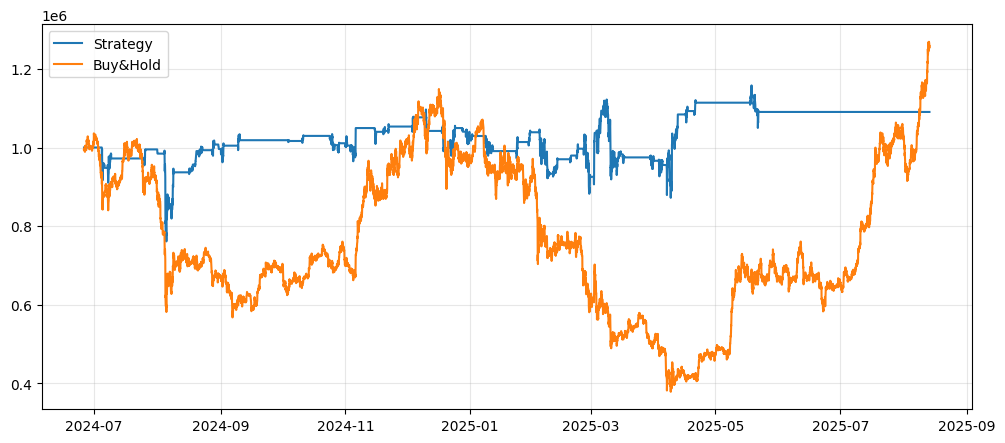

In [ ]:

import os
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from collections import deque

from sklearn.metrics import classification_report, confusion_matrix
from xgboost import XGBClassifier

# 設定
CSV_PATH = "2025futures.csv"
DATETIME_COLUMN = "timestamp"
PRICE_COLUMN = "close_eth"
TIMEZONE = None

# 特徴量リスト
final_feature_columns = [
    # 1. 基本データ
    'ret_1h', 'volume_eth', 'volume_btc', 'ret_btc_1h', 'ret_btc_24h',
    'ratio_z_score',

    # 2. 時間的特徴量
    'hour_sin', 'hour_cos', 'day_sin', 'day_cos',

    # 3. トレンド/環境認識 (ADX)
    'ADX_14', 'ADX_5', "ADX_50", "ADX_168",

    # 4. 【NEW】PCAの代わりに追加したテクニカル指標
    'ma_dev_eth',      # 移動平均乖離率 (買われすぎ判定)
    'vol_dist_eth',    # ボラティリティ距離 (異常値判定)
    'rsi_eth',         # RSI (逆張り判定)
    'macd_hist_eth'    # MACDヒストグラム (トレンド転換判定)
]

HORIZON = 11
CLASSIFICATION_THRESHOLD = 0.003

#XGB_PARAMS = dict(
    #learning_rate = 0.05,
    #n_estimators = 400,
    #max_depth = 4,
    #subsample = 0.7,
    #colsample_bytree = 0.6,
    #min_child_weight = 3,
    #gamma = 0.1,
    #reg_alpha = 0.1,
    #reg_lambda = 1.0,
#)

XGB_PARAMS = dict(
    learning_rate = 0.02,
    n_estimators = 800,
    max_depth = 6,
    subsample = 0.8,
    colsample_bytree = 0.8,
    min_child_weight = 1,
    gamma = 0.0,
    reg_alpha = 0.0,
    reg_lambda = 1.0

)


COMMISSION = 0.0005
SLIPPAGE = 0.005
USE_PORTFOLIO_95 = True

SIGNAL_LEN = 12
UP_PROB_THRESH = 0.7
UP_HITS_REQUIRED = 9
DOWN_PROB_THRESH = 0.65
DOWN_STREAK_REQUIRED = 3

FEATURE_BUFFER_HOURS = 600
TEST_SIZE_FRACTION = 0.25
RETRAIN_EVERY_N = 1000
MIN_TRAIN_SIZE = 8000
INITIAL_EQUITY = 1_000_000.0

VOL_WEIGHT = 0.2  # ボラティリティ収束シグナル重み

# データ読み込み
def load_data(path):
    df = pd.read_csv(path)
    df[DATETIME_COLUMN] = pd.to_datetime(df[DATETIME_COLUMN])
    if TIMEZONE:
        if df[DATETIME_COLUMN].dt.tz is None:
            df[DATETIME_COLUMN] = df[DATETIME_COLUMN].dt.tz_localize(TIMEZONE)
        else:
            df[DATETIME_COLUMN] = df[DATETIME_COLUMN].dt.tz_convert(TIMEZONE)
    df = df.sort_values(DATETIME_COLUMN).set_index(DATETIME_COLUMN)

    return df

# 価格変動の二値分類(上昇:1 非上昇:0)
def make_target(df):
    future_ret = df[PRICE_COLUMN].shift(-HORIZON) / df[PRICE_COLUMN] - 1.0
    y = pd.Series(index=df.index, dtype='float64')
    y[future_ret > CLASSIFICATION_THRESHOLD] = 1.0  # 上昇
    y[future_ret <= CLASSIFICATION_THRESHOLD] = 0.0 # 非上昇 (横ばい or 下落)
    return y

# Walk-forward 学習
def walk_forward_proba(df, X_cols, y):
    X_cols = [c for c in X_cols if c in df.columns]
    df2 = df.iloc[FEATURE_BUFFER_HOURS:].copy()
    y2 = y.loc[df2.index]
    X_all = df2[X_cols]
    n = len(df2)
    test_start = max(int(n*(1-TEST_SIZE_FRACTION)), MIN_TRAIN_SIZE)
    test_idx = X_all.index[test_start:]
    proba_records = []
    model = None
    last_fit_i = None
    for i, ts in enumerate(test_idx):
        if (model is None) or (last_fit_i is None) or (i - last_fit_i >= RETRAIN_EVERY_N):
            end_loc = test_start + i
            X_train = X_all.iloc[:end_loc]
            y_train = y2.iloc[:end_loc - HORIZON]
            valid_idx = X_train.dropna().index.intersection(y_train.dropna().index)
            if len(valid_idx) >= 20 and len(y_train.loc[valid_idx].unique()) > 1:
                model = XGBClassifier(**XGB_PARAMS)
                model.fit(X_train.loc[valid_idx].values, y_train.loc[valid_idx].values)
            else:
                model = None
            last_fit_i = i
        x_row = X_all.loc[[ts]].values
        if model is None:
            p = np.array([[0.5, 0.5]]) # 2クラス用のデフォルト確率
        else:
            p = model.predict_proba(x_row)
        proba_records.append((ts,float(p[0,0]),float(p[0,1])))
    # 2クラス用のDataFrameを作成
    proba_df = pd.DataFrame(proba_records, columns=["timestamp","p_not_up","p_up"]).set_index("timestamp")
    y_true = y2.loc[proba_df.index]
    return proba_df, y_true

# ボラティリティ収束シグナル→移動平均シグナルに変更(P=R=0 前はP=0.8,R=2.0)
def add_vol_signals(df, ma_period=24*7, vol_period=24*7, P=0, R=0):
    d = df.copy()
    d["ma_vol"] = d[PRICE_COLUMN].rolling(ma_period).mean()
    d["vol_sigma"] = d[PRICE_COLUMN].rolling(vol_period).std()
    d["vol_sigma"].replace(0,np.nan)
    d["reb_signal"] = ((d[PRICE_COLUMN] < d["ma_vol"] - P * d["vol_sigma"])).astype(int).fillna(0)
    d["rev_signal"] = ((d[PRICE_COLUMN] > d["ma_vol"] + R * d["vol_sigma"])).astype(int).fillna(0)
    return d[["ma_vol","vol_sigma","reb_signal","rev_signal"]]

# バックテスト
def backtest_composite(df, proba_df):
    df_sub = df.loc[proba_df.index].copy()
    vol_df = add_vol_signals(df_sub)
    df_sub = df_sub.join(vol_df)
    prices = df_sub[PRICE_COLUMN]
    fill_prices = prices.shift(-1)
    cash, pos = INITIAL_EQUITY, 0.0
    equity = pd.Series(index=proba_df.index,dtype=float)
    logs = []
    up_hits = deque(maxlen=SIGNAL_LEN)
    down_streak = 0

    comp_up = np.clip(proba_df["p_up"] + VOL_WEIGHT * df_sub["reb_signal"],0,1)
    # p_down の代わりに p_not_up を使用
    comp_down = np.clip(proba_df["p_not_up"] + VOL_WEIGHT * df_sub["rev_signal"],0,1)

    for i, t in enumerate(proba_df.index):
        p_up_c = float(comp_up.iloc[i])
        p_down_c = float(comp_down.iloc[i])
        up_hits.append(p_up_c >= UP_PROB_THRESH)
        down_streak = down_streak + 1 if p_down_c >= DOWN_PROB_THRESH else 0

        price = prices.loc[t]
        next_price = fill_prices.loc[t] if t in fill_prices.index else np.nan
        if np.isnan(next_price):
            equity.loc[t] = cash + pos*price
            continue
        if (sum(up_hits)>=UP_HITS_REQUIRED) and pos==0:
            use_ratio = 0.95 if USE_PORTFOLIO_95 else 1.0
            notional = cash*use_ratio
            fill = next_price*(1+SLIPPAGE)
            qty = (notional*(1-COMMISSION))/fill
            cash -= qty*fill; pos += qty
            logs.append({"timestamp":t,"side":"BUY","price":float(fill),"qty":float(qty),"cash_after":float(cash)})
        elif (down_streak>=DOWN_STREAK_REQUIRED) and pos>0:
            fill = next_price*(1-SLIPPAGE)
            cash += pos*fill*(1-COMMISSION)
            logs.append({"timestamp":t,"side":"SELL","price":float(fill),"qty":float(pos),"cash_after":float(cash)})
            pos=0
        equity.loc[t] = cash + pos*price

    # Buy&Hold
    bh_entry = prices.iloc[0]*(1+SLIPPAGE)
    bh_qty = (INITIAL_EQUITY*(1-COMMISSION))/bh_entry
    bh_equity = bh_qty*prices

    trades_df = pd.DataFrame(logs).set_index("timestamp") if logs else pd.DataFrame(columns=["side","price","qty","cash_after"])
    return equity, bh_equity, trades_df

# 指標
def metrics(equity):
    eq = equity.dropna()
    rets = eq.pct_change().dropna()
    periods_per_year = 24*365
    cagr = (eq.iloc[-1]/eq.iloc[0])**(periods_per_year/len(eq))-1
    maxdd = (1 - eq/eq.cummax()).max()
    sharpe = (rets.mean()/(rets.std()+1e-12))*math.sqrt(periods_per_year)
    return {"CAGR": cagr, "MaxDD": maxdd, "Sharpe": sharpe}

# メイン
def main():
    df = load_data(CSV_PATH)
    y = make_target(df)
    valid_idx = df.index.intersection(df[final_feature_columns].dropna().index).intersection(y.dropna().index)
    df_clean = df.loc[valid_idx]
    X_clean = df_clean[final_feature_columns]
    y_clean = y.loc[valid_idx]

    proba_df, y_true = walk_forward_proba(df_clean, final_feature_columns, y_clean)

    # Classification report
    # 確率0.7を閾値として予測ラベルを生成
    y_hat = (proba_df['p_up'] > 0.7).astype(int)
    print("\n=== Classification Report (0: Not Up, 1: Up) ===")
    print(classification_report(y_true.values, y_hat, digits=4))
    print("Confusion Matrix:\n", confusion_matrix(y_true.values, y_hat))

    equity, bh_equity, trades_df = backtest_composite(df_clean, proba_df)

    print("\nStrategy:", {k:round(v,4) for k,v in metrics(equity).items()})
    print("Buy&Hold:", {k:round(v,4) for k,v in metrics(bh_equity).items()})

    # plot
    plt.figure(figsize=(12,5))
    plt.plot(equity,label="Strategy")
    plt.plot(bh_equity,label="Buy&Hold")
    plt.legend(); plt.grid(True,alpha=0.3); plt.show()

    # save trades
    trades_df.to_csv(os.path.splitext(CSV_PATH)[0]+"_trades.csv")

if __name__=="__main__":
    main()


---

### 分類レポート（Classification Report）の各項目の意味

モデルが「価格が上昇する（1.0）」か「上昇しない（0.0）」かをどれだけ正確に予測できたかを示します。

* **Precision (適合率):** 予測の的中率。「1.0」と予測したうち、実際に上昇した割合。
* **Recall (再現率):** 網羅率。実際の上昇局面のうち、モデルが「1.0」と予測して的中させた割合。
* **F1-score:** 適合率と再現率の調和平均。モデルの総合的な強さを示します。
* **Support:** テストデータに含まれる各クラスの実際のデータ数。
* **Accuracy (正解率):** 全データのうち、予測が的中した割合。

### 今回の予測結果の分析

* **上昇予測(1.0):** Recallが **0.0343 (約3.4%)** と非常に低くなっています。このモデルは、上昇のチャンスのほとんどを見逃していると言えます。
一方で上昇予測のPrecisionは **0.5725** あり、ランダムよりは高い精度です。モデルは慎重なエントリー戦略を持っています。

* **非上昇予測(0.0):** Recallが **0.9788** Precisionは **0.5512** です。ほとんどの非上昇局面で無駄なエントリーを減らすことができています。わかりずらいですが、集計方法から、AIが70パーセントを超えて非上昇と予測した内、55パーセントが非上昇だったということになります。

### 3. 混同行列（Confusion Matrix）の解説

予測と実績の内訳です。

|  | 予測：0.0 (Not Up) | 予測：1.0 (Up) |
| --- | --- | --- |
| **実績：0.0 (Not Up)** | **5321** (正解: 上がらないと予測し的中) | **115** (誤認: 上がらないのに「上がる」と予測) |
| **実績：1.0 (Up)** | **4333** (見逃し: 上がるのに予測できず) | **154** (正解: 上がると予測し的中) |

* **154回** しか上昇を的中させていませんが、誤認（空振り）も **115回** と非常に少なく抑えられています。これがドローダウンの抑制に寄与しています。





ちなみに、逆張り型のボラティリティシグナルを用いた場合は以下のモデルとなります。こちらが当初計画していたモデルです。


=== Classification Report (0: Not Up, 1: Up) ===
              precision    recall  f1-score   support

         0.0     0.5512    0.9788    0.7052      5436
         1.0     0.5725    0.0343    0.0648      4487

    accuracy                         0.5517      9923
   macro avg     0.5618    0.5066    0.3850      9923
weighted avg     0.5608    0.5517    0.4156      9923

Confusion Matrix:
 [[5321  115]
 [4333  154]]

Strategy: {'CAGR': np.float64(-0.0601), 'MaxDD': 0.331, 'Sharpe': np.float64(0.0475)}
Buy&Hold: {'CAGR': np.float64(0.2312), 'MaxDD': 0.671, 'Sharpe': np.float64(0.6505)}


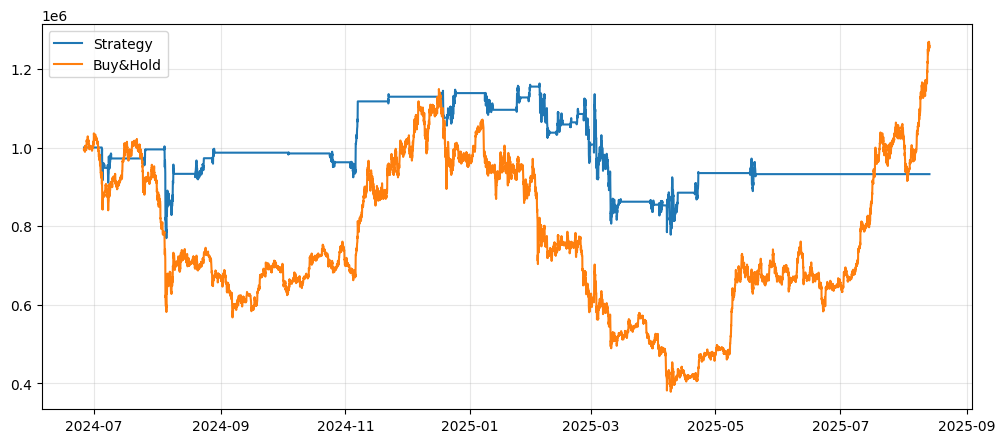

In [ ]:
#XGboost×ボラティリティシグナ ADX5,50,168追加

import os
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from collections import deque

from sklearn.metrics import classification_report, confusion_matrix
from xgboost import XGBClassifier

# 設定
CSV_PATH = "2025futures.csv"
DATETIME_COLUMN = "timestamp"
PRICE_COLUMN = "close_eth"
TIMEZONE = None

# 特徴量リスト
final_feature_columns = [
    # 1. 基本データ
    'ret_1h', 'volume_eth', 'volume_btc', 'ret_btc_1h', 'ret_btc_24h',
    'ratio_z_score',

    # 2. 時間的特徴量
    'hour_sin', 'hour_cos', 'day_sin', 'day_cos',

    # 3. トレンド/環境認識 (ADX)
    'ADX_14', 'ADX_5', "ADX_50", "ADX_168",

    # 4. 【NEW】PCAの代わりに追加したテクニカル指標
    'ma_dev_eth',      # 移動平均乖離率 (買われすぎ判定)
    'vol_dist_eth',    # ボラティリティ距離 (異常値判定)
    'rsi_eth',         # RSI (逆張り判定)
    'macd_hist_eth'    # MACDヒストグラム (トレンド転換判定)
]

HORIZON = 11
CLASSIFICATION_THRESHOLD = 0.003

#XGB_PARAMS = dict(
    #learning_rate = 0.05,
    #n_estimators = 400,
    #max_depth = 4,
    #subsample = 0.7,
    #colsample_bytree = 0.6,
    #min_child_weight = 3,
    #gamma = 0.1,
    #reg_alpha = 0.1,
    #reg_lambda = 1.0,
#)

XGB_PARAMS = dict(
    learning_rate = 0.02,
    n_estimators = 800,
    max_depth = 6,
    subsample = 0.8,
    colsample_bytree = 0.8,
    min_child_weight = 1,
    gamma = 0.0,
    reg_alpha = 0.0,
    reg_lambda = 1.0

)


COMMISSION = 0.0005
SLIPPAGE = 0.005
USE_PORTFOLIO_95 = True

SIGNAL_LEN = 12
UP_PROB_THRESH = 0.7
UP_HITS_REQUIRED = 9
DOWN_PROB_THRESH = 0.65
DOWN_STREAK_REQUIRED = 3

FEATURE_BUFFER_HOURS = 600
TEST_SIZE_FRACTION = 0.25
RETRAIN_EVERY_N = 1000
MIN_TRAIN_SIZE = 8000
INITIAL_EQUITY = 1_000_000.0

VOL_WEIGHT = 0.2  # ボラティリティ収束シグナル重み

# データ読み込み
def load_data(path):
    df = pd.read_csv(path)
    df[DATETIME_COLUMN] = pd.to_datetime(df[DATETIME_COLUMN])
    if TIMEZONE:
        if df[DATETIME_COLUMN].dt.tz is None:
            df[DATETIME_COLUMN] = df[DATETIME_COLUMN].dt.tz_localize(TIMEZONE)
        else:
            df[DATETIME_COLUMN] = df[DATETIME_COLUMN].dt.tz_convert(TIMEZONE)
    df = df.sort_values(DATETIME_COLUMN).set_index(DATETIME_COLUMN)

    return df

# 価格変動の二値分類(上昇:1 非上昇:0)
def make_target(df):
    future_ret = df[PRICE_COLUMN].shift(-HORIZON) / df[PRICE_COLUMN] - 1.0
    y = pd.Series(index=df.index, dtype='float64')
    y[future_ret > CLASSIFICATION_THRESHOLD] = 1.0  # 上昇
    y[future_ret <= CLASSIFICATION_THRESHOLD] = 0.0 # 非上昇 (横ばい or 下落)
    return y

# Walk-forward 学習
def walk_forward_proba(df, X_cols, y):
    X_cols = [c for c in X_cols if c in df.columns]
    df2 = df.iloc[FEATURE_BUFFER_HOURS:].copy()
    y2 = y.loc[df2.index]
    X_all = df2[X_cols]
    n = len(df2)
    test_start = max(int(n*(1-TEST_SIZE_FRACTION)), MIN_TRAIN_SIZE)
    test_idx = X_all.index[test_start:]
    proba_records = []
    model = None
    last_fit_i = None
    for i, ts in enumerate(test_idx):
        if (model is None) or (last_fit_i is None) or (i - last_fit_i >= RETRAIN_EVERY_N):
            end_loc = test_start + i
            X_train = X_all.iloc[:end_loc]
            y_train = y2.iloc[:end_loc - HORIZON]
            valid_idx = X_train.dropna().index.intersection(y_train.dropna().index)
            if len(valid_idx) >= 20 and len(y_train.loc[valid_idx].unique()) > 1:
                model = XGBClassifier(**XGB_PARAMS)
                model.fit(X_train.loc[valid_idx].values, y_train.loc[valid_idx].values)
            else:
                model = None
            last_fit_i = i
        x_row = X_all.loc[[ts]].values
        if model is None:
            p = np.array([[0.5, 0.5]]) # 2クラス用のデフォルト確率
        else:
            p = model.predict_proba(x_row)
        proba_records.append((ts,float(p[0,0]),float(p[0,1])))
    # 2クラス用のDataFrameを作成
    proba_df = pd.DataFrame(proba_records, columns=["timestamp","p_not_up","p_up"]).set_index("timestamp")
    y_true = y2.loc[proba_df.index]
    return proba_df, y_true

# ボラティリティ収束シグナル→移動平均シグナルに変更(P=R=0 前はP=0.8,R=2.0)
def add_vol_signals(df, ma_period=24*7, vol_period=24*7, P=0.8, R=2.0):
    d = df.copy()
    d["ma_vol"] = d[PRICE_COLUMN].rolling(ma_period).mean()
    d["vol_sigma"] = d[PRICE_COLUMN].rolling(vol_period).std()
    d["vol_sigma"].replace(0,np.nan)
    d["reb_signal"] = ((d[PRICE_COLUMN] < d["ma_vol"] - P * d["vol_sigma"])).astype(int).fillna(0)
    d["rev_signal"] = ((d[PRICE_COLUMN] > d["ma_vol"] + R * d["vol_sigma"])).astype(int).fillna(0)
    return d[["ma_vol","vol_sigma","reb_signal","rev_signal"]]

# バックテスト
def backtest_composite(df, proba_df):
    df_sub = df.loc[proba_df.index].copy()
    vol_df = add_vol_signals(df_sub)
    df_sub = df_sub.join(vol_df)
    prices = df_sub[PRICE_COLUMN]
    fill_prices = prices.shift(-1)
    cash, pos = INITIAL_EQUITY, 0.0
    equity = pd.Series(index=proba_df.index,dtype=float)
    logs = []
    up_hits = deque(maxlen=SIGNAL_LEN)
    down_streak = 0

    comp_up = np.clip(proba_df["p_up"] + VOL_WEIGHT * df_sub["reb_signal"],0,1)
    # p_down の代わりに p_not_up を使用
    comp_down = np.clip(proba_df["p_not_up"] + VOL_WEIGHT * df_sub["rev_signal"],0,1)

    for i, t in enumerate(proba_df.index):
        p_up_c = float(comp_up.iloc[i])
        p_down_c = float(comp_down.iloc[i])
        up_hits.append(p_up_c >= UP_PROB_THRESH)
        down_streak = down_streak + 1 if p_down_c >= DOWN_PROB_THRESH else 0

        price = prices.loc[t]
        next_price = fill_prices.loc[t] if t in fill_prices.index else np.nan
        if np.isnan(next_price):
            equity.loc[t] = cash + pos*price
            continue
        if (sum(up_hits)>=UP_HITS_REQUIRED) and pos==0:
            use_ratio = 0.95 if USE_PORTFOLIO_95 else 1.0
            notional = cash*use_ratio
            fill = next_price*(1+SLIPPAGE)
            qty = (notional*(1-COMMISSION))/fill
            cash -= qty*fill; pos += qty
            logs.append({"timestamp":t,"side":"BUY","price":float(fill),"qty":float(qty),"cash_after":float(cash)})
        elif (down_streak>=DOWN_STREAK_REQUIRED) and pos>0:
            fill = next_price*(1-SLIPPAGE)
            cash += pos*fill*(1-COMMISSION)
            logs.append({"timestamp":t,"side":"SELL","price":float(fill),"qty":float(pos),"cash_after":float(cash)})
            pos=0
        equity.loc[t] = cash + pos*price

    # Buy&Hold
    bh_entry = prices.iloc[0]*(1+SLIPPAGE)
    bh_qty = (INITIAL_EQUITY*(1-COMMISSION))/bh_entry
    bh_equity = bh_qty*prices

    trades_df = pd.DataFrame(logs).set_index("timestamp") if logs else pd.DataFrame(columns=["side","price","qty","cash_after"])
    return equity, bh_equity, trades_df

# 指標
def metrics(equity):
    eq = equity.dropna()
    rets = eq.pct_change().dropna()
    periods_per_year = 24*365
    cagr = (eq.iloc[-1]/eq.iloc[0])**(periods_per_year/len(eq))-1
    maxdd = (1 - eq/eq.cummax()).max()
    sharpe = (rets.mean()/(rets.std()+1e-12))*math.sqrt(periods_per_year)
    return {"CAGR": cagr, "MaxDD": maxdd, "Sharpe": sharpe}

# メイン
def main():
    df = load_data(CSV_PATH)
    y = make_target(df)
    valid_idx = df.index.intersection(df[final_feature_columns].dropna().index).intersection(y.dropna().index)
    df_clean = df.loc[valid_idx]
    X_clean = df_clean[final_feature_columns]
    y_clean = y.loc[valid_idx]

    proba_df, y_true = walk_forward_proba(df_clean, final_feature_columns, y_clean)

    # Classification report
    # 確率0.7を閾値として予測ラベルを生成
    y_hat = (proba_df['p_up'] > 0.7).astype(int)
    print("\n=== Classification Report (0: Not Up, 1: Up) ===")
    print(classification_report(y_true.values, y_hat, digits=4))
    print("Confusion Matrix:\n", confusion_matrix(y_true.values, y_hat))

    equity, bh_equity, trades_df = backtest_composite(df_clean, proba_df)

    print("\nStrategy:", {k:round(v,4) for k,v in metrics(equity).items()})
    print("Buy&Hold:", {k:round(v,4) for k,v in metrics(bh_equity).items()})

    # plot
    plt.figure(figsize=(12,5))
    plt.plot(equity,label="Strategy")
    plt.plot(bh_equity,label="Buy&Hold")
    plt.legend(); plt.grid(True,alpha=0.3); plt.show()

    # save trades
    trades_df.to_csv(os.path.splitext(CSV_PATH)[0]+"_trades.csv")

if __name__=="__main__":
    main()

#モデルを大きく変える
##前モデルの問題点
* 上記のモデルでは、XGboostによる11時間後の価格変動の予測を行ったが、その予測精度は低かった(上昇の予測は57%程度)。
* 市場の動きはブラウン運動に近い。そのため動きをAIで学習し予測することは無謀でした。
* 取引約定までの時間が考慮されていない。
* スリッページなしでテストしていた。(追加済み)

##新しいモデルのアイデア
有効だった移動平均シグナルと堅牢な取引ロジック(直近12回のシグナル合計または連続による売買)をそのまま利用。
大部分が無駄になったAI(XGboost)の計算を移動平均シグナルを実行した場合の取引の成功失敗自体を学習させる。
##メタラベリングを採用
メタラベリングとは
* マルコス・ロペス・デ・プラドが提唱
* 1次ロジックが特徴量から取引シグナルを生成。(今回は移動平均シグナルを利用)
* 1次ロジックのシグナルに従って取引した結果、n期間後までにその取引が利益を上げられるか、それ自体をAIに学習させる。

###その他改善案
* 取引の実行をシグナル生成の次時間に実行するとすることで、約定の遅れを再現します。
* 関数名をadd_volatility_signalからadd_MA_signalsへ変更
* 1次ロジックとして複数のモデルをひとまとめに使用する(未実行、数理モデルが必要)
* クラウド環境での実働を見据えて、学習済みのXGboostを用意し、時系列データ取得と特徴量計算、取引シグナル生成を同時に行うモデルを作っておく。(未実行)

#メタラベリングを用いたモデル

11時間後の価格変動予測という不可能なタスクからXGboostを開放して、新たな学習方法を実装します。
この方法をメタラベリングといいます。
これまでの実験で、この局面において移動平均が非常に強力であることがわかりました。今回は移動平均に従って売買する場合、利益を上げられるかをXGboostに学習させます。


###メタラベリングとは
数理モデルが出力する買いシグナルまたは売りシグナルを実行して、利益を上げられるかそれ自体を学習させる方法です。


=== Meta-Labeling Classification Report (0: Trade Fail, 1: Trade Success) ===
              precision    recall  f1-score   support

         0.0     0.4622    0.9906    0.6303      4454
         1.0     0.8892    0.0616    0.1152      5471

    accuracy                         0.4785      9925
   macro avg     0.6757    0.5261    0.3727      9925
weighted avg     0.6976    0.4785    0.3464      9925

Confusion Matrix:
 [[4412   42]
 [5134  337]]

Strategy: {'CAGR': np.float64(0.7827), 'MaxDD': 0.2481, 'Sharpe': np.float64(1.9565)}
Buy&Hold: {'CAGR': np.float64(0.2408), 'MaxDD': 0.671, 'Sharpe': np.float64(0.6613)}


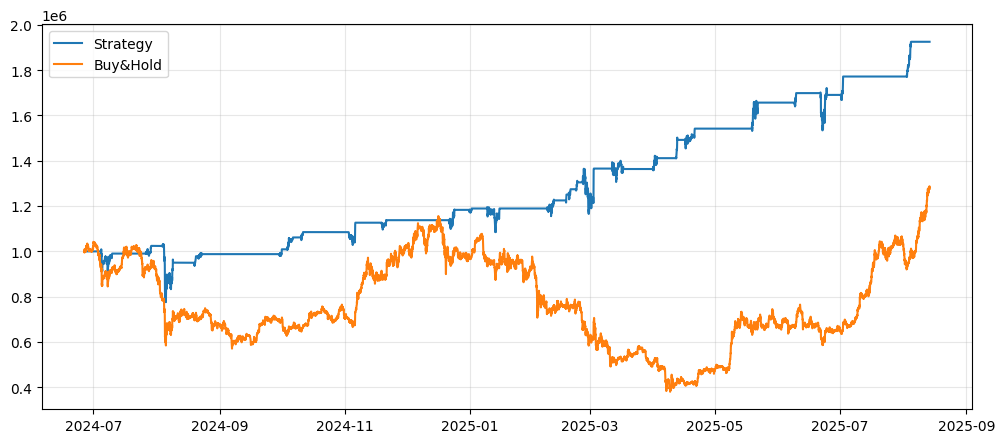

In [ ]:
import os
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from collections import deque

from sklearn.metrics import classification_report, confusion_matrix
from xgboost import XGBClassifier

# 設定
CSV_PATH = "2025futures.csv"
DATETIME_COLUMN = "timestamp"
PRICE_COLUMN = "close_eth"
TIMEZONE = None

# 特徴量リスト
final_feature_columns = [
    'ret_1h', 'volume_eth', 'volume_btc', 'ret_btc_1h', 'ret_btc_24h',
    'ratio_z_score', 'hour_sin', 'hour_cos', 'day_sin', 'day_cos',
    'ADX_14', 'ADX_5', "ADX_50", "ADX_168",
    'ma_dev_eth', 'vol_dist_eth', 'rsi_eth', 'macd_hist_eth'
]

# メタラベリング用設定（AIがエントリーを許可する閾値）
META_PROB_THRESH = 0.9
MAX_HOLD_HOURS = 24 * 14  # 垂直バリア：最大ホールド期間（14日間）

XGB_PARAMS = dict(
    learning_rate = 0.02,
    n_estimators = 800,
    max_depth = 6,
    subsample = 0.8,
    colsample_bytree = 0.8,
    min_child_weight = 1,
    gamma = 0.0,
    reg_alpha = 0.0,
    reg_lambda = 1.0
)

COMMISSION = 0.0005
SLIPPAGE = 0.0005
USE_PORTFOLIO_95 = True

SIGNAL_LEN = 12
UP_HITS_REQUIRED = 9
DOWN_STREAK_REQUIRED = 3

FEATURE_BUFFER_HOURS = 600
TEST_SIZE_FRACTION = 0.25
RETRAIN_EVERY_N = 1000
MIN_TRAIN_SIZE = 8000
INITIAL_EQUITY = 1_000_000.0

# データ読み込み
def load_data(path):
    df = pd.read_csv(path)
    df[DATETIME_COLUMN] = pd.to_datetime(df[DATETIME_COLUMN])
    if TIMEZONE:
        if df[DATETIME_COLUMN].dt.tz is None:
            df[DATETIME_COLUMN] = df[DATETIME_COLUMN].dt.tz_localize(TIMEZONE)
        else:
            df[DATETIME_COLUMN] = df[DATETIME_COLUMN].dt.tz_convert(TIMEZONE)
    df = df.sort_values(DATETIME_COLUMN).set_index(DATETIME_COLUMN)
    return df

# ボラティリティ収束シグナル→移動平均シグナル
def add_MA_signals(df, ma_period=24*7, vol_period=24*7, P=0, R=0):
    d = df.copy()
    d["ma_vol"] = d[PRICE_COLUMN].rolling(ma_period).mean()
    d["vol_sigma"] = d[PRICE_COLUMN].rolling(vol_period).std()
    d["vol_sigma"] = d["vol_sigma"].replace(0, np.nan)
    d["reb_signal"] = ((d[PRICE_COLUMN] < d["ma_vol"] - P * d["vol_sigma"])).astype(int).fillna(0)
    d["rev_signal"] = ((d[PRICE_COLUMN] > d["ma_vol"] + R * d["vol_sigma"])).astype(int).fillna(0)
    return d[["ma_vol","vol_sigma","reb_signal","rev_signal"]]

# 変更点（１）メタラベリングのターゲット生成
# 修正＝＝メタラベリングのターゲット生成垂直バリア付き＝＝＝＝＝＝＝
def make_meta_target(df):
    vol_df = add_MA_signals(df)
    df_sub = df.join(vol_df)
    prices = df_sub[PRICE_COLUMN]
    fill_prices = prices.shift(-1)

    rev_signals = df_sub["rev_signal"].values
    down_streaks = np.zeros(len(df_sub), dtype=int)
    current_streak = 0
    for i in range(len(rev_signals)):
        if rev_signals[i] == 1:
            current_streak += 1
        else:
            current_streak = 0
        down_streaks[i] = current_streak

    exit_indices = np.where(down_streaks >= DOWN_STREAK_REQUIRED)[0]

    y = pd.Series(np.nan, index=df.index)
    fill_prices_arr = fill_prices.values

    for i in range(len(df)):
        idx_pos = np.searchsorted(exit_indices, i + 1)

        # デフォルトは「14日後（MAX_HOLD_HOURS）の時間切れエグジット」
        exit_i = i + MAX_HOLD_HOURS

        # もし14日以内に正規のエグジット条件（down_streak >= 3）が成立していれば、そちらを採用
        if idx_pos < len(exit_indices):
            signal_exit_i = exit_indices[idx_pos]
            if signal_exit_i <= i + MAX_HOLD_HOURS:
                exit_i = signal_exit_i

        # 計算に必要な未来のデータ（exit_i）がデータセットの末尾を越えている場合はラベリング不能
        if exit_i >= len(df):
            continue

        entry_price = fill_prices_arr[i] * (1 + SLIPPAGE)
        exit_price = fill_prices_arr[exit_i] * (1 - SLIPPAGE)

        if np.isnan(entry_price) or np.isnan(exit_price):
            continue

        pnl = (exit_price - entry_price) / entry_price - COMMISSION * 2

        y.iloc[i] = 1.0 if pnl > 0 else 0.0

    return y

# Walk-forward 学習 (変更なし、yがメタラベルに置き換わるだけ)
# ＝＝＝＝＝＝＝修正　Walk-forward への学習パージの追加＝＝＝＝＝＝＝
def walk_forward_proba(df, X_cols, y):
    X_cols = [c for c in X_cols if c in df.columns]
    df2 = df.iloc[FEATURE_BUFFER_HOURS:].copy()
    y2 = y.loc[df2.index]
    X_all = df2[X_cols]
    n = len(df2)
    test_start = max(int(n*(1-TEST_SIZE_FRACTION)), MIN_TRAIN_SIZE)
    test_idx = X_all.index[test_start:]
    proba_records = []
    model = None
    last_fit_i = None

    for i, ts in enumerate(test_idx):
        if (model is None) or (last_fit_i is None) or (i - last_fit_i >= RETRAIN_EVERY_N):
            end_loc = test_start + i
            X_train = X_all.iloc[:end_loc]

            # 【重要】MAX_HOLD_HOURS分だけ学習データから切り捨てて、未来情報の混入（リーケージ）を防ぐ
            y_train = y2.iloc[:end_loc - MAX_HOLD_HOURS]

            valid_idx = X_train.dropna().index.intersection(y_train.dropna().index)
            if len(valid_idx) >= 20 and len(y_train.loc[valid_idx].unique()) > 1:
                model = XGBClassifier(**XGB_PARAMS)
                model.fit(X_train.loc[valid_idx].values, y_train.loc[valid_idx].values)
            else:
                model = None
            last_fit_i = i

        x_row = X_all.loc[[ts]].values
        if model is None:
            p = np.array([[0.5, 0.5]])
        else:
            p = model.predict_proba(x_row)

        proba_records.append((ts, float(p[0,0]), float(p[0,1])))

    proba_df = pd.DataFrame(proba_records, columns=["timestamp","p_fail","p_success"]).set_index("timestamp")
    y_true = y2.loc[proba_df.index]
    return proba_df, y_true

# 変更点（２）直列メタラベリング・バックテスト
def backtest_meta(df, proba_df):
    df_sub = df.loc[proba_df.index].copy()
    vol_df = add_MA_signals(df_sub)
    df_sub = df_sub.join(vol_df)
    prices = df_sub[PRICE_COLUMN]
    fill_prices = prices.shift(-1)

    cash, pos = INITIAL_EQUITY, 0.0
    equity = pd.Series(index=proba_df.index, dtype=float)
    logs = []

    up_hits = deque(maxlen=SIGNAL_LEN)
    down_streak = 0

    for i, t in enumerate(proba_df.index):
        # 1. ベースロジックのシグナル
        base_up = df_sub["reb_signal"].iloc[i]
        base_down = df_sub["rev_signal"].iloc[i]

        up_hits.append(base_up == 1)
        down_streak = down_streak + 1 if base_down == 1 else 0

        # AIの成功確率予測 (p_up ではなく p_success になりました)
        p_success = float(proba_df["p_success"].iloc[i])

        price = prices.loc[t]
        next_price = fill_prices.loc[t] if t in fill_prices.index else np.nan
        if np.isnan(next_price):
            equity.loc[t] = cash + pos*price
            continue

        # 2. 直列ゲート：ベースがシグナルを出し、かつAIが「勝てる」と同意した場合のみエントリー
        base_condition = (sum(up_hits) >= UP_HITS_REQUIRED)
        ai_condition = (p_success >= META_PROB_THRESH)

        if base_condition and ai_condition and pos == 0:
            use_ratio = 0.95 if USE_PORTFOLIO_95 else 1.0
            notional = cash * use_ratio
            fill = next_price * (1 + SLIPPAGE)
            qty = (notional * (1 - COMMISSION)) / fill
            cash -= qty * fill
            pos += qty
            logs.append({"timestamp":t, "side":"BUY", "price":float(fill), "qty":float(qty), "cash_after":float(cash)})

        # エグジットはAIを無視し、ベースロジックの絶対ルール（down_streak）に従う
        elif (down_streak >= DOWN_STREAK_REQUIRED) and pos > 0:
            fill = next_price * (1 - SLIPPAGE)
            cash += pos * fill * (1 - COMMISSION)
            logs.append({"timestamp":t, "side":"SELL", "price":float(fill), "qty":float(pos), "cash_after":float(cash)})
            pos = 0

        equity.loc[t] = cash + pos * price

    bh_entry = prices.iloc[0] * (1 + SLIPPAGE)
    bh_qty = (INITIAL_EQUITY * (1 - COMMISSION)) / bh_entry
    bh_equity = bh_qty * prices

    trades_df = pd.DataFrame(logs).set_index("timestamp") if logs else pd.DataFrame(columns=["side","price","qty","cash_after"])
    return equity, bh_equity, trades_df

# 指標
def metrics(equity):
    eq = equity.dropna()
    rets = eq.pct_change().dropna()
    periods_per_year = 24*365
    cagr = (eq.iloc[-1]/eq.iloc[0])**(periods_per_year/len(eq))-1
    maxdd = (1 - eq/eq.cummax()).max()
    sharpe = (rets.mean()/(rets.std()+1e-12))*math.sqrt(periods_per_year)
    return {"CAGR": cagr, "MaxDD": maxdd, "Sharpe": sharpe}

# メイン
def main():
    df = load_data(CSV_PATH)
    y = make_meta_target(df) # メタラベル生成に変更

    valid_idx = df.index.intersection(df[final_feature_columns].dropna().index).intersection(y.dropna().index)
    df_clean = df.loc[valid_idx]
    y_clean = y.loc[valid_idx]

    proba_df, y_true = walk_forward_proba(df_clean, final_feature_columns, y_clean)

    # 評価 (0: 失敗トレード, 1: 成功トレード)
    y_hat = (proba_df['p_success'] > META_PROB_THRESH).astype(int)
    print("\n=== Meta-Labeling Classification Report (0: Trade Fail, 1: Trade Success) ===")
    print(classification_report(y_true.values, y_hat, digits=4))
    print("Confusion Matrix:\n", confusion_matrix(y_true.values, y_hat))

    equity, bh_equity, trades_df = backtest_meta(df_clean, proba_df)

    print("\nStrategy:", {k:round(v,4) for k,v in metrics(equity).items()})
    print("Buy&Hold:", {k:round(v,4) for k,v in metrics(bh_equity).items()})

    plt.figure(figsize=(12,5))
    plt.plot(equity, label="Strategy")
    plt.plot(bh_equity, label="Buy&Hold")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

    trades_df.to_csv(os.path.splitext(CSV_PATH)[0]+"_trades.csv")

if __name__=="__main__":
    main()

#性能評価

### メタラベリング予測結果の分析

**成功予測 (1.0):**
Recall（再現率）が **0.0616 (約6.2%)** と非常に低く、実際に成功するトレード機会の大部分（約94%）を見逃しています。しかし、Precision（予測精度）が **0.8892 (約88.9%)** と極めて高いです。AIが勝てると判断してエントリーを許可したトレードは、約89%の確率で実際に利益になることを意味しており、性格で安全なフィルターとして機能しています。

**失敗予測 (0.0):**
Recallが **0.9906 (約99.1%)** 。一次ロジック(移動平均シグナル)が発する失敗に終わるシグナルをほぼ完璧に捕捉し、見送ることに成功しています。

### 混同行列（Confusion Matrix）


| | 予測：0.0 (Trade Fail) | 予測：1.0 (Trade Success) |
|---|---|---|
| **実績：0.0 (Fail)** | **4412** (正解: 負けトレードを見事に見送り) | **42** (誤認: 負けるのに「勝てる」と判定し損失) |
| **実績：1.0 (Success)** | **5134** (見逃し: 勝てるトレードを疑って見送り) | **337** (正解: 勝てるトレードを的確に捕捉して利益) |

勝てるトレードを **337回** しか拾えていませんが、注目すべきは負けトレードへの誤認（ダマシへの引っかかり）がわずか **42回** に抑え込むことができました。閾値をかなり高めに設定したことも影響します。保守的なトレードが、最終的な利益を大きく増やして、リスクを確実に回避することが出来ました。

### 戦略パフォーマンスへの寄与
厳格なAIフィルターと取引ロジックが、無駄なエントリーとそれに伴う取引コストを減らしました。
その結果、Buy&Holdの最大ドローダウン(下落幅)が **67.1%** であるのに対し、本戦略は **24.8%** まで大幅にリスクを抑制しています。防御力を極限まで高めながらも、CAGR（年平均成長率）は **78.27%**、シャープレシオは **1.95** という、非常に堅牢で高いパフォーマンスを実現しています。

In [ ]:
import os
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from collections import deque

from sklearn.metrics import classification_report, confusion_matrix
from xgboost import XGBClassifier

# 設定
CSV_PATH = "2025futures.csv"
DATETIME_COLUMN = "timestamp"
PRICE_COLUMN = "close_eth"
TIMEZONE = None

# 特徴量リスト
final_feature_columns = [
    'ret_1h', 'volume_eth', 'volume_btc', 'ret_btc_1h', 'ret_btc_24h',
    'ratio_z_score', 'hour_sin', 'hour_cos', 'day_sin', 'day_cos',
    'ADX_14', 'ADX_5', "ADX_50", "ADX_168",
    'ma_dev_eth', 'vol_dist_eth', 'rsi_eth', 'macd_hist_eth'
]

# メタラベリング用設定（AIがエントリーを許可する閾値）
META_PROB_THRESH = 0.9
MAX_HOLD_HOURS = 24 * 14  # 垂直バリア：最大ホールド期間（14日間）

XGB_PARAMS = dict(
    learning_rate = 0.02,
    n_estimators = 800,
    max_depth = 6,
    subsample = 0.8,
    colsample_bytree = 0.8,
    min_child_weight = 1,
    gamma = 0.0,
    reg_alpha = 0.0,
    reg_lambda = 1.0
)

COMMISSION = 0.0005
SLIPPAGE = 0.0005
USE_PORTFOLIO_95 = True

SIGNAL_LEN = 12
UP_HITS_REQUIRED = 9
DOWN_STREAK_REQUIRED = 3

FEATURE_BUFFER_HOURS = 600
TEST_SIZE_FRACTION = 0.25
RETRAIN_EVERY_N = 1000
MIN_TRAIN_SIZE = 8000
INITIAL_EQUITY = 1_000_000.0

# データ読み込み
def load_data(path):
    df = pd.read_csv(path)
    df[DATETIME_COLUMN] = pd.to_datetime(df[DATETIME_COLUMN])
    if TIMEZONE:
        if df[DATETIME_COLUMN].dt.tz is None:
            df[DATETIME_COLUMN] = df[DATETIME_COLUMN].dt.tz_localize(TIMEZONE)
        else:
            df[DATETIME_COLUMN] = df[DATETIME_COLUMN].dt.tz_convert(TIMEZONE)
    df = df.sort_values(DATETIME_COLUMN).set_index(DATETIME_COLUMN)
    return df

# ボラティリティ収束シグナル→移動平均シグナル
def add_MA_signals(df, ma_period=24*7, vol_period=24*7, P=0, R=0):
    d = df.copy()
    d["ma_vol"] = d[PRICE_COLUMN].rolling(ma_period).mean()
    d["vol_sigma"] = d[PRICE_COLUMN].rolling(vol_period).std()
    d["vol_sigma"] = d["vol_sigma"].replace(0, np.nan)
    d["reb_signal"] = ((d[PRICE_COLUMN] < d["ma_vol"] - P * d["vol_sigma"])).astype(int).fillna(0)
    d["rev_signal"] = ((d[PRICE_COLUMN] > d["ma_vol"] + R * d["vol_sigma"])).astype(int).fillna(0)
    return d[["ma_vol","vol_sigma","reb_signal","rev_signal"]]

# 変更点（１）メタラベリングのターゲット生成
# 修正＝＝メタラベリングのターゲット生成垂直バリア付き＝＝＝＝＝＝＝
def make_meta_target(df):
    vol_df = add_MA_signals(df)
    df_sub = df.join(vol_df)
    prices = df_sub[PRICE_COLUMN]
    fill_prices = prices.shift(-1)

    rev_signals = df_sub["rev_signal"].values
    down_streaks = np.zeros(len(df_sub), dtype=int)
    current_streak = 0
    for i in range(len(rev_signals)):
        if rev_signals[i] == 1:
            current_streak += 1
        else:
            current_streak = 0
        down_streaks[i] = current_streak

    exit_indices = np.where(down_streaks >= DOWN_STREAK_REQUIRED)[0]

    y = pd.Series(np.nan, index=df.index)
    fill_prices_arr = fill_prices.values

    for i in range(len(df)):
        idx_pos = np.searchsorted(exit_indices, i + 1)

        # デフォルトは「14日後（MAX_HOLD_HOURS）の時間切れエグジット」
        exit_i = i + MAX_HOLD_HOURS

        # もし14日以内に正規のエグジット条件（down_streak >= 3）が成立していれば、そちらを採用
        if idx_pos < len(exit_indices):
            signal_exit_i = exit_indices[idx_pos]
            if signal_exit_i <= i + MAX_HOLD_HOURS:
                exit_i = signal_exit_i

        # 計算に必要な未来のデータ（exit_i）がデータセットの末尾を越えている場合はラベリング不能
        if exit_i >= len(df):
            continue

        entry_price = fill_prices_arr[i] * (1 + SLIPPAGE)
        exit_price = fill_prices_arr[exit_i] * (1 - SLIPPAGE)

        if np.isnan(entry_price) or np.isnan(exit_price):
            continue

        pnl = (exit_price - entry_price) / entry_price - COMMISSION * 2

        y.iloc[i] = 1.0 if pnl > 0 else 0.0

    return y

# Walk-forward 学習 (変更なし、yがメタラベルに置き換わるだけ)
# ＝＝＝＝＝＝＝修正　Walk-forward への学習パージの追加＝＝＝＝＝＝＝
def walk_forward_proba(df, X_cols, y):
    X_cols = [c for c in X_cols if c in df.columns]
    df2 = df.iloc[FEATURE_BUFFER_HOURS:].copy()
    y2 = y.loc[df2.index]
    X_all = df2[X_cols]
    n = len(df2)
    test_start = max(int(n*(1-TEST_SIZE_FRACTION)), MIN_TRAIN_SIZE)
    test_idx = X_all.index[test_start:]
    proba_records = []
    model = None
    last_fit_i = None

    for i, ts in enumerate(test_idx):
        if (model is None) or (last_fit_i is None) or (i - last_fit_i >= RETRAIN_EVERY_N):
            end_loc = test_start + i
            X_train = X_all.iloc[:end_loc]

            # 【重要】MAX_HOLD_HOURS分だけ学習データから切り捨てて、未来情報の混入（リーケージ）を防ぐ
            y_train = y2.iloc[:end_loc - MAX_HOLD_HOURS]

            valid_idx = X_train.dropna().index.intersection(y_train.dropna().index)
            if len(valid_idx) >= 20 and len(y_train.loc[valid_idx].unique()) > 1:
                model = XGBClassifier(**XGB_PARAMS)
                model.fit(X_train.loc[valid_idx].values, y_train.loc[valid_idx].values)
            else:
                model = None
            last_fit_i = i

        x_row = X_all.loc[[ts]].values
        if model is None:
            p = np.array([[0.5, 0.5]])
        else:
            p = model.predict_proba(x_row)

        proba_records.append((ts, float(p[0,0]), float(p[0,1])))

    proba_df = pd.DataFrame(proba_records, columns=["timestamp","p_fail","p_success"]).set_index("timestamp")
    y_true = y2.loc[proba_df.index]
    return proba_df, y_true

# 変更点（２）直列メタラベリング・バックテスト
def backtest_meta(df, proba_df):
    df_sub = df.loc[proba_df.index].copy()
    vol_df = add_MA_signals(df_sub)
    df_sub = df_sub.join(vol_df)
    prices = df_sub[PRICE_COLUMN]
    fill_prices = prices.shift(-1)

    cash, pos = INITIAL_EQUITY, 0.0
    equity = pd.Series(index=proba_df.index, dtype=float)
    logs = []

    up_hits = deque(maxlen=SIGNAL_LEN)
    down_streak = 0

    for i, t in enumerate(proba_df.index):
        # 1. ベースロジックのシグナル
        base_up = df_sub["reb_signal"].iloc[i]
        base_down = df_sub["rev_signal"].iloc[i]

        up_hits.append(base_up == 1)
        down_streak = down_streak + 1 if base_down == 1 else 0

        # AIの成功確率予測 (p_up ではなく p_success になりました)
        p_success = float(proba_df["p_success"].iloc[i])

        price = prices.loc[t]
        next_price = fill_prices.loc[t] if t in fill_prices.index else np.nan
        if np.isnan(next_price):
            equity.loc[t] = cash + pos*price
            continue

        # 2. 直列ゲート：ベースがシグナルを出し、かつAIが「勝てる」と同意した場合のみエントリー
        base_condition = (sum(up_hits) >= UP_HITS_REQUIRED)
        ai_condition = (p_success >= META_PROB_THRESH)

        if base_condition and ai_condition and pos == 0:
            use_ratio = 0.95 if USE_PORTFOLIO_95 else 1.0
            notional = cash * use_ratio
            fill = next_price * (1 + SLIPPAGE)
            qty = (notional * (1 - COMMISSION)) / fill
            cash -= qty * fill
            pos += qty
            logs.append({"timestamp":t, "side":"BUY", "price":float(fill), "qty":float(qty), "cash_after":float(cash)})

        # エグジットはAIを無視し、ベースロジックの絶対ルール（down_streak）に従う
        elif (down_streak >= DOWN_STREAK_REQUIRED) and pos > 0:
            fill = next_price * (1 - SLIPPAGE)
            cash += pos * fill * (1 - COMMISSION)
            logs.append({"timestamp":t, "side":"SELL", "price":float(fill), "qty":float(pos), "cash_after":float(cash)})
            pos = 0

        equity.loc[t] = cash + pos * price

    bh_entry = prices.iloc[0] * (1 + SLIPPAGE)
    bh_qty = (INITIAL_EQUITY * (1 - COMMISSION)) / bh_entry
    bh_equity = bh_qty * prices

    trades_df = pd.DataFrame(logs).set_index("timestamp") if logs else pd.DataFrame(columns=["side","price","qty","cash_after"])
    return equity, bh_equity, trades_df

# 指標
def metrics(equity):
    eq = equity.dropna()
    rets = eq.pct_change().dropna()
    periods_per_year = 24*365
    cagr = (eq.iloc[-1]/eq.iloc[0])**(periods_per_year/len(eq))-1
    maxdd = (1 - eq/eq.cummax()).max()
    sharpe = (rets.mean()/(rets.std()+1e-12))*math.sqrt(periods_per_year)
    return {"CAGR": cagr, "MaxDD": maxdd, "Sharpe": sharpe}

# メイン
def main():
    df = load_data(CSV_PATH)
    y = make_meta_target(df) # メタラベル生成に変更

    valid_idx = df.index.intersection(df[final_feature_columns].dropna().index).intersection(y.dropna().index)
    df_clean = df.loc[valid_idx]
    y_clean = y.loc[valid_idx]

    proba_df, y_true = walk_forward_proba(df_clean, final_feature_columns, y_clean)

    # 評価 (0: 失敗トレード, 1: 成功トレード)
    y_hat = (proba_df['p_success'] > META_PROB_THRESH).astype(int)
    print("\n=== Meta-Labeling Classification Report (0: Trade Fail, 1: Trade Success) ===")
    print(classification_report(y_true.values, y_hat, digits=4))
    print("Confusion Matrix:\n", confusion_matrix(y_true.values, y_hat))

    equity, bh_equity, trades_df = backtest_meta(df_clean, proba_df)

    print("\nStrategy:", {k:round(v,4) for k,v in metrics(equity).items()})
    print("Buy&Hold:", {k:round(v,4) for k,v in metrics(bh_equity).items()})

    plt.figure(figsize=(12,5))
    plt.plot(equity, label="Strategy")
    plt.plot(bh_equity, label="Buy&Hold")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

    trades_df.to_csv(os.path.splitext(CSV_PATH)[0]+"_trades.csv")

if __name__=="__main__":
    main()